`Integrate this month's Python/ML work into your group's assigned project.
`


-  Dataset
-  
   ↓
- Load Data
- 
   ↓
- Explore Data
- 
   ↓
- Preprocess Data
- 
   ↓
- Train ML Model
- 
   ↓
- Make Predictions
- 
   ↓
- Evaluate Model
- 
   ↓
- Confusion Matrix
- 
   ↓
- Test
- 
   ↓
- Save Model

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Load the Iris dataset

iris = load_iris()

X = iris.data
y = iris.target

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


In [ ]:
# create a DataFrame for better visualization and analysis
df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df["target"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [36]:
# Dataset shape:
df.shape

(150, 5)

In [37]:
# Missing values:
df.isnull().sum()


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [38]:
# Dataset information:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


## Visualization the Dataset

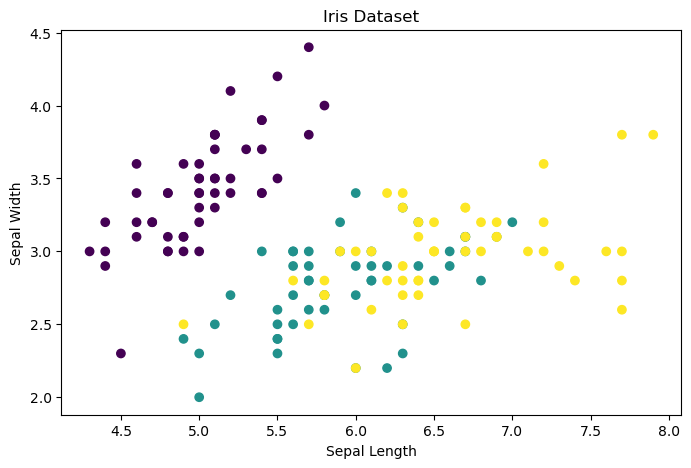

In [ ]:
# visualization of the Dataset

plt.figure(figsize=(8, 5))

plt.scatter(df["sepal length (cm)"], df["sepal width (cm)"], c=df["target"])

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Iris Dataset")

plt.show()

In [40]:
X = df.drop("target", axis=1)
y = df["target"]

## Train Test split the dataset

In [ ]:
# Train Test split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [43]:
# preprocess the data using StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [44]:
scaler.fit_transform(X_train)

array([[-1.72156775, -0.33210111, -1.34572231, -1.32327558],
       [-1.12449223, -1.22765467,  0.41450518,  0.6517626 ],
       [ 1.14439475, -0.5559895 ,  0.58484978,  0.25675496],
       [-1.12449223,  0.11567567, -1.28894078, -1.45494479],
       [-0.40800161, -1.22765467,  0.13059752,  0.12508575],
       [ 0.54731923, -1.22765467,  0.69841284,  0.91510102],
       [-0.2885865 , -0.77987789,  0.24416059,  0.12508575],
       [ 0.54731923, -0.5559895 ,  0.75519438,  0.38842418],
       [ 2.21913069, -0.10821272,  1.3230097 ,  1.44177787],
       [ 2.21913069,  1.6828944 ,  1.66369889,  1.31010866],
       [ 2.09971558, -0.10821272,  1.60691736,  1.17843945],
       [ 0.18907392, -0.33210111,  0.41450518,  0.38842418],
       [-1.00507713, -2.34709662, -0.15331014, -0.26992188],
       [-0.04975629, -0.77987789,  0.18737906, -0.26992188],
       [-0.04975629, -1.00376628,  0.13059752, -0.00658346],
       [-1.36332244,  0.33956406, -1.23215924, -1.32327558],
       [-0.88566202,  1.

In [45]:
# Train the model using DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

In [46]:
# Make Predictions
y_pred = model.predict(X_test_scaled)

print("Predictions:")
print(y_pred)

Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]


In [50]:
# Calculate Accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Test Accuracy:", accuracy)

# Classification Report
print("classification report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Test Accuracy: 0.9333333333333333
classification report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


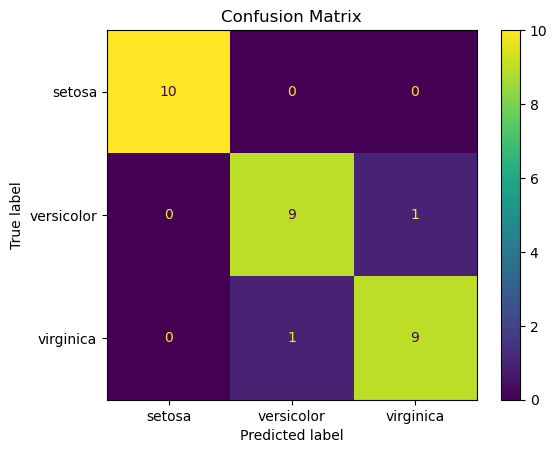

In [51]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

## Test a New Sample

In [52]:
new_flower = [[
    5.1,
    3.5,
    1.4,
    0.2
]]

new_flower_scaled = scaler.transform(new_flower)

prediction = model.predict(
    new_flower_scaled
)

print(
    "Predicted class:",
    iris.target_names[prediction[0]]
)

Predicted class: setosa


c:\Users\Zone Tech\.conda\envs\tensorflow_env\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [61]:
# save the model and scaler using joblib
import joblib

joblib.dump(model, "./models/iris_model.pkl")
joblib.dump(scaler, "./models/scaler.pkl")

['./models/scaler.pkl']

In [62]:
# Test the Saved Model
loaded_model = joblib.load("./models/iris_model.pkl")
loaded_scaler = joblib.load("./models/scaler.pkl")

new_sample = [[
    5.1,
    3.5,
    1.4,
    0.2
]]

new_sample_scaled = loaded_scaler.transform(new_sample)

prediction = loaded_model.predict(
    new_sample_scaled
)

print(
    "Prediction from saved model:",
    iris.target_names[prediction[0]]
)

Prediction from saved model: setosa


c:\Users\Zone Tech\.conda\envs\tensorflow_env\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
